In [ ]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

# 🧪 Étape 6 : Évaluation Métrique & Robustesse (Squelette Étudiant)

Cette étape correspond au sixième chapitre du cours. L'objectif est de mettre en place un protocole d'évaluation rigoureux (splits d'évaluation adaptés) et de calculer les métriques clés de performance pour valider scientifiquement la qualité de vos modèles.

### 1. IMPORTATIONS ET CHARGEMENT DU MODÈLE CHAMPION

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join('..')))
import src.train_models as tm

# 1. Rechargement des données et ré-entraînement rapide du champion XGBoost
df_final = pd.read_csv("../data/processed/football_final_features.csv")
df_train, df_test, df_scouting, X_train, X_test, X_scouting, y_train, y_test, num_cols, cat_cols = tm.prepare_data(df_final)

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

preprocessor = tm.build_preprocessing_pipeline(num_cols, cat_cols)
xgb_champion = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1))
])
xgb_champion.fit(X_train, y_train)

# 2. Prédictions (en échelle Log et échelle Réelle)
y_pred_log = xgb_champion.predict(X_test)
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

### 2. CRÉATION DU TABLEAU D'ANALYSE DES RÉSIDUS

In [3]:
# On reconstruit un DataFrame de test pour analyser les erreurs par catégorie
df_eval = df_test.copy()
df_eval['Vrai_Prix'] = y_test_real
df_eval['Prix_Predit'] = y_pred_real
df_eval['Erreur_Absolue'] = np.abs(df_eval['Vrai_Prix'] - df_eval['Prix_Predit'])
df_eval['Erreur_Signee'] = df_eval['Prix_Predit'] - df_eval['Vrai_Prix'] # >0 = Surévaluation, <0 = Sous-évaluation

print("[INFO] Tableau d'évaluation des résidus créé.")
df_eval[['position', 'age', 'Vrai_Prix', 'Prix_Predit', 'Erreur_Absolue']].head()

[INFO] Tableau d'évaluation des résidus créé.


,position,age,Vrai_Prix,Prix_Predit,Erreur_Absolue
22640,Attack,28.0,4000000.0,1.171907e+07,7.719066e+06
12375,Defender,32.0,250000.0,3.051020e+05,5.510197e+04
4771,Midfield,38.0,800000.0,2.134271e+05,5.865729e+05
13063,Defender,38.0,25000.0,1.769364e+05,1.519364e+05
4877,Defender,41.0,100000.0,1.804253e+05,8.042534e+04


### 3. VISUALISATION 1 - VALEURS PRÉDITES VS VALEURS RÉELLES

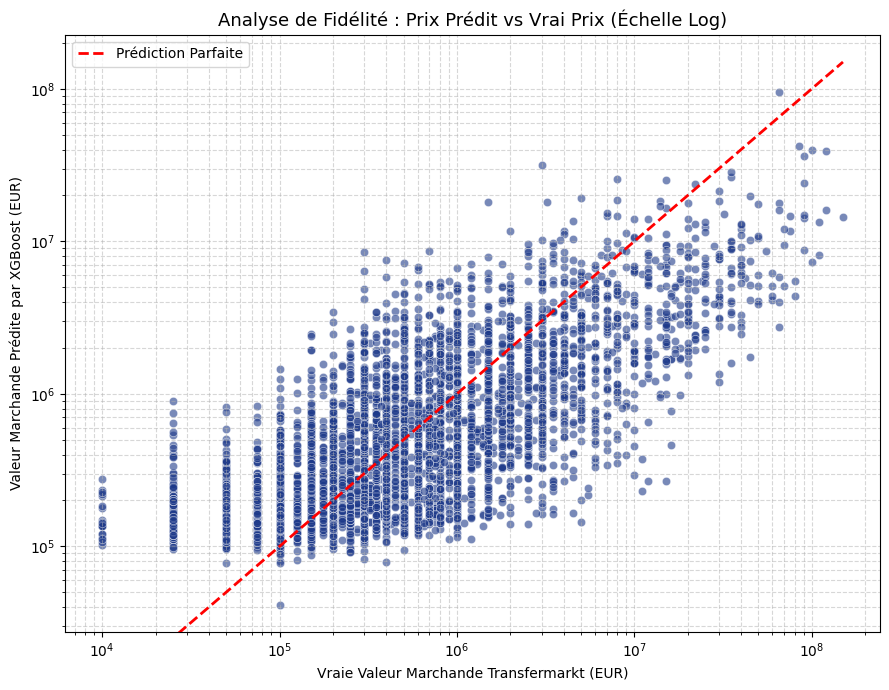

In [4]:
plt.figure(figsize=(9, 7))
# On utilise une échelle log pour le graphique pour que ce soit lisible malgré les écarts géants
sns.scatterplot(x=df_eval['Vrai_Prix'], y=df_eval['Prix_Predit'], alpha=0.6, color='#1e3a8a')
# Ligne diagonale parfaite (Erreur = 0)
max_val = max(df_eval['Vrai_Prix'].max(), df_eval['Prix_Predit'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label="Prédiction Parfaite")

plt.xscale('log')
plt.yscale('log')
plt.title("Analyse de Fidélité : Prix Prédit vs Vrai Prix (Échelle Log)", fontsize=13)
plt.xlabel("Vraie Valeur Marchande Transfermarkt (EUR)")
plt.ylabel("Valeur Marchande Prédite par XGBoost (EUR)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()

os.makedirs("../report/figures/", exist_ok=True)
plt.savefig("../report/figures/predicted_vs_actual.png", dpi=300)
plt.show()

### 4. VISUALISATION 2 - OÙ LE MODÈLE SE TROMPE-T-IL LE PLUS ? (Par Position)

/tmp/ipykernel_16055/2313353892.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eval, x='position', y='Erreur_Signee', palette='Set2')


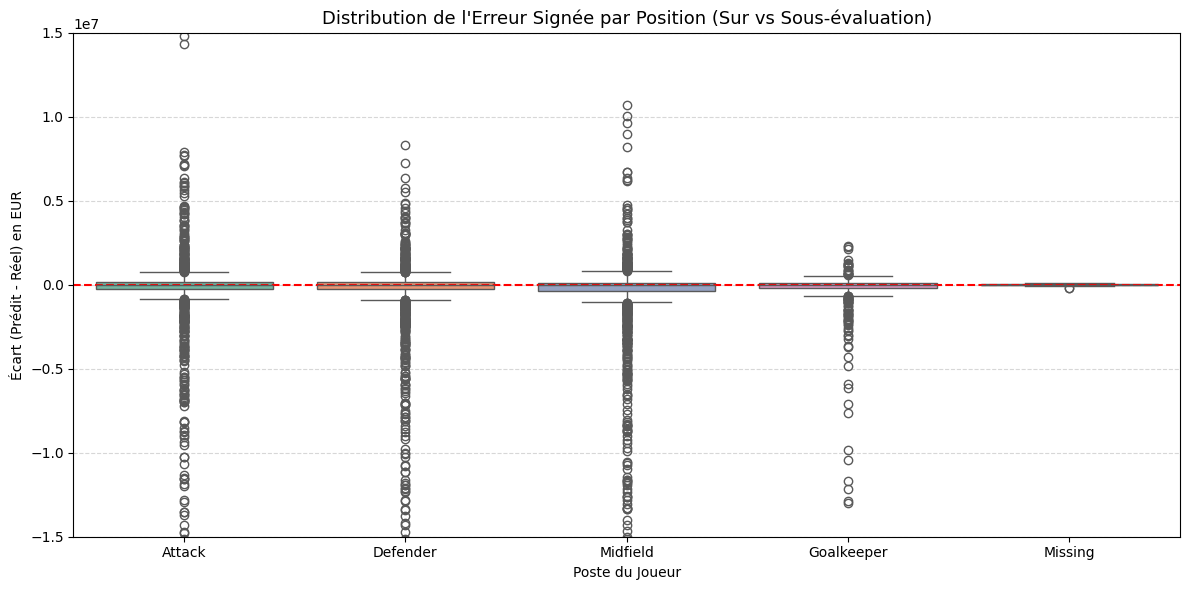

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_eval, x='position', y='Erreur_Signee', palette='Set2')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title("Distribution de l'Erreur Signée par Position (Sur vs Sous-évaluation)", fontsize=13)
plt.xlabel("Poste du Joueur")
plt.ylabel("Écart (Prédit - Réel) en EUR")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Limiter l'affichage des axes pour ne pas être écrasé par les superstars à 100M€
plt.ylim(-15000000, 15000000) 

plt.tight_layout()
plt.savefig("../report/figures/errors_by_position.png", dpi=300)
plt.show()